# The Term Premium — a quantitative teardown 🔬
### ACM-style premium proxy · quintile sort · HAC *t* · block-shuffle placebo · horizon & sub-period sweeps · timing-overlay costs · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Term--premium_times_duration%3F: Mixed](https://img.shields.io/badge/Term--premium_times_duration%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build an ACM-style term-premium proxy (10y yield minus an EWMA of the short rate), rank it out-of-sample, and test whether the fattest-premium days precede higher forward TLT returns.

> ⚠️ **Not investment advice.** Real data: yfinance daily TLT + `^TNX` + `^IRX`, 6,009 days (2002-07-31 → 2026-06-26, tape fp `83b8f0823f11`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from term_premium import data, strategy as st

def load_real():
    """Cache-first real daily tape (empty frame offline)."""
    try:
        return data.fetch_daily(fetch=False)
    except FileNotFoundError:
        return pd.DataFrame()

DF = load_real()
HAVE_REAL = not DF.empty
print("real term-premium tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF)} days, {DF.index[0].date()} -> {DF.index[-1].date()})")


real term-premium tape present: True (6009 days, 2002-07-31 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Q5−Q1 forward-TLT spread **+0.26%** (21d), HAC *t* **+0.43**, placebo *p* 0.719 — right sign, sub-2 *t*; sign flips across sub-periods (real only 2002-09, *t* +2.09). ACM-*proxy* ⇒ `REAL` unreachable in principle. |
| **Tradability** | `MIRAGE` | Timer Sharpe **0.291** vs buy-and-hold **0.247** — a cash-drag artefact; mean-return spread **-0.32 bps/day** (*t* -0.39) at 9.6 switches/yr. |
| **Term-premium times duration?** | `MIXED` | Present 2002-09 (*t* +2.09); faded 2010-16; inverted 2017-21 (*t* −0.82). |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this ACM-proxy tape the timing edge is right-signed, faint, and regime-dependent.

## 1 · The claim, steelmanned

Let $\text{TP}_t$ be the term-premium proxy and $r_{t\to t+h}$ the forward TLT return.

- **H₁ (the sort).** $\mathbb{E}[r \mid \text{TP high (Q5)}] - \mathbb{E}[r \mid \text{TP low (Q1)}] > 0$ at HAC *t* ≥ 2.
- **H₂ (robustness).** The sign of the Q5−Q1 spread is stable across horizons and sub-periods.
- **H₃ (tradable).** A premium-conditioned timing overlay beats buy-and-hold TLT net of costs, on mean return (not just Sharpe).

We find **H₁ directionally right but not significant** (spread positive, HAC *t* +0.43), **H₂ rejected** (sign flips across sub-periods), and **H₃ rejected** (the timer's Sharpe edge is a cash-drag artefact; its mean-return spread is negative).

## 2 · So what? — what rides on each answer

The content is the **decomposition**: a long yield is expected-short-rates + term premium. The raw curve slope ([132](../../132-yield-curve-steepener/)) mixes the two; subtracting an EWMA-expectations component isolates the *premium* — the risk-compensation piece that Fama-Bliss and Cochrane-Piazzesi show is time-varying and predictable. If it times duration, you have a clean rates signal; if not, the ACM machinery doesn't survive a no-key proxy on live data.

## 3 · How we'd know — the protocol

- **Signal.** $\text{TP} = y_{10} - \text{EWMA}_{252}(\text{short})$, ranked out-of-sample over a trailing 252-day window into $\text{rank}\in[0,1]$ (higher = fatter), lagged one day.
- **Sort.** Quintiles of the lagged rank; compare Q5 (fattest) vs Q1 (thinnest) forward TLT return.
- **Inference.** HAC (Newey-West) *t* on the day-level Q5−Q1 difference (overlapping forward returns demand it); a **block-shuffle placebo** null (circular rotation, 21-day blocks).
- **Robustness.** Horizons 5/21/63/126d; four sub-periods.
- **Frictions.** A timing overlay (own TLT when rank > 0.5, else cash), one-way cost per switch × NAV; net Sharpe vs buy-and-hold and the mean-return spread.
- **Positive control.** A deterministic synthetic world with a planted timing edge (`tp_signal > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the premium at close *t* forms the signal; the position enters at close *t+1*; the forward return runs from *t+1*. That one-bar lag is the single documented execution convention — the EWMA and the rolling rank are causal, so no future data enters the signal.

## 4 · The teardown

### 4a · The sort — H₁

Q5 vs Q1 forward TLT return (21-day), with the HAC *t* and the block-shuffle placebo.

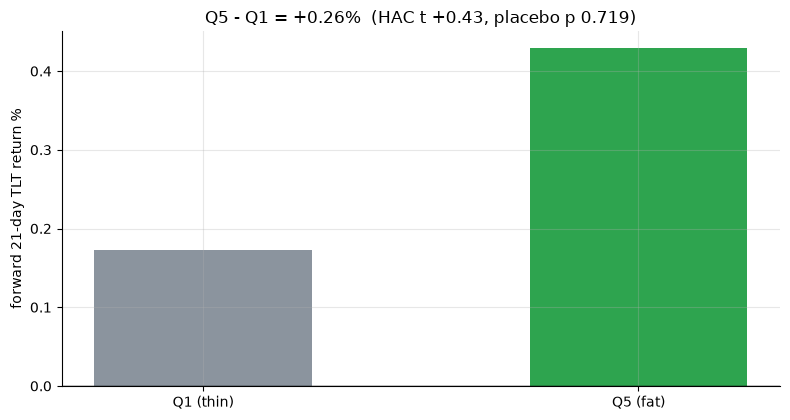

Q1 +0.17% | Q5 +0.43% | spread +0.26% | HAC t +0.43 | placebo p 0.719


In [2]:
if HAVE_REAL:
    qs = st.quintile_spread(DF, horizon=21)
    p = st.placebo_pvalue(DF, horizon=21, n_perm=1000, seed=581)
    q1, q5, spr, t = qs['q1']*100, qs['q5']*100, qs['spread']*100, qs['t']
else:
    q1, q5, spr, t, p = 0.17, 0.43, 0.26, 0.43, 0.719
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Q1 (thin)','Q5 (fat)'], [q1, q5], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 21-day TLT return %')
ax.set_title(f'Q5 - Q1 = {spr:+.2f}%  (HAC t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Q1 +{q1:.2f}% | Q5 +{q5:.2f}% | spread {spr:+.2f}% | HAC t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **directionally right, not significant.** The spread is **+0.26%** (HAC *t* +0.43), and the placebo *p* = 0.719 says a spread this size is well inside the null — the fat premium points the right way but the edge is buried in noise.

### 4b · Horizon sweep — does the sign hold as you extend the hold?

The same Q5−Q1 spread over 5, 21, 63 and 126-day forward horizons.

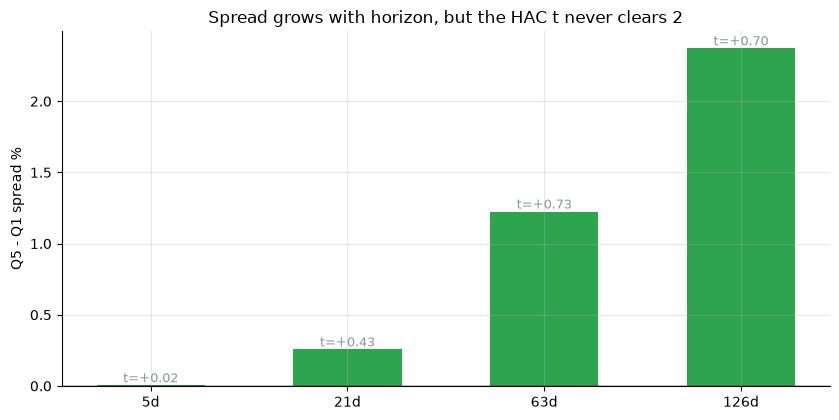

horizon spreads %: [0.0, 0.26, 1.22, 2.37] | HAC t: [0.02, 0.43, 0.73, 0.7]


In [3]:
horiz = [('5d', 0.0, 0.02), ('21d', 0.26, 0.43), ('63d', 1.22, 0.73), ('126d', 2.37, 0.7)]
if HAVE_REAL:
    tab = st.horizon_sweep(DF, horizons=(5,21,63,126))
    labs = list(tab.index); spr = list(tab['spread']*100); ts = list(tab['t'])
else:
    labs = [h[0] for h in horiz]; spr = [h[1] for h in horiz]; ts = [h[2] for h in horiz]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(labs, spr, color=GREEN, width=.55)
for x,(s,tt) in enumerate(zip(spr, ts)):
    ax.annotate(f't={tt:+.2f}', (x, s), ha='center', va='bottom', fontsize=9, color=GREY)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Q5 - Q1 spread %')
ax.set_title('Spread grows with horizon, but the HAC t never clears 2')
plt.tight_layout(); plt.show()
print('horizon spreads %:', [round(s,2) for s in spr], '| HAC t:', [round(x,2) for x in ts])

> 💡 In plain words: the spread rises with horizon (a fat premium drifts into higher long-horizon returns) but the HAC correction deflates the *t* — the longer-horizon 'edge' is mostly overlap-induced persistence, not fresh information. Right sign, no significance.

### 4c · Sub-period sweep — H₂ (is the sign stable?)

The Q5−Q1 spread within four sub-periods.

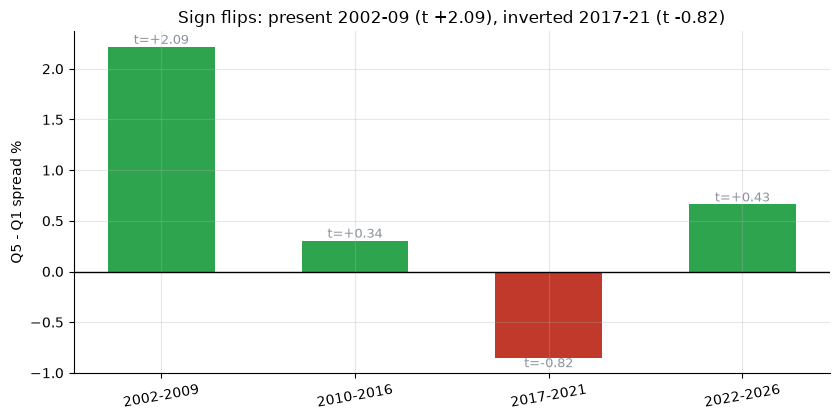

sub-period spreads %: [2.22, 0.3, -0.85, 0.66] | HAC t: [2.09, 0.34, -0.82, 0.43]


In [4]:
sub = [('2002-2009', 2.22, 2.09), ('2010-2016', 0.3, 0.34), ('2017-2021', -0.85, -0.82), ('2022-2026', 0.66, 0.43)]
if HAVE_REAL:
    edges = [('2002-2009','2002-07-01','2009-12-31'),('2010-2016','2010-01-01','2016-12-31'),
             ('2017-2021','2017-01-01','2021-12-31'),('2022-2026','2022-01-01','2026-06-26')]
    tab = st.subperiod_sweep(DF, edges, horizon=21)
    labs = list(tab.index); spr = list(tab['spread']*100); ts = list(tab['t'])
else:
    labs = [s[0] for s in sub]; spr = [s[1] for s in sub]; ts = [s[2] for s in sub]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(range(len(labs)), spr, color=cols, width=.55)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=10)
for x,(s,tt) in enumerate(zip(spr, ts)):
    ax.annotate(f't={tt:+.2f}', (x, s), ha='center', va='bottom' if s>=0 else 'top', fontsize=9, color=GREY)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Q5 - Q1 spread %')
ax.set_title('Sign flips: present 2002-09 (t +2.09), inverted 2017-21 (t -0.82)')
plt.tight_layout(); plt.show()
print('sub-period spreads %:', [round(s,2) for s in spr], '| HAC t:', [round(x,2) for x in ts])

> 💡 In plain words: H₂ **rejected.** The edge is significant *only* in 2002-2009 (*t* +2.09), fades in 2010-2016, and **inverts** in the ZIRP 2017-2021 era (*t* −0.82). A sign that depends on the regime is `MIXED`, not a signal.

## 5 · The verdict

- **Signal `WEAK`** — H₁ right-signed but sub-2 (spread +0.26%, HAC *t* +0.43, placebo *p* 0.719); H₂ rejected (sign flips). ACM-proxy ⇒ `REAL` is out of reach in principle.
- **Tradability `MIRAGE`** — timer Sharpe 0.291 vs buy-and-hold 0.247 is a cash-drag artefact; mean-return spread -0.32 bps/day.
- **Term-premium times duration? `MIXED`** — present in 1 of 4 windows, gone or backwards in the rest.

## 6 · Could you trade it? — the timing-overlay costs

Own TLT when the premium rank > 0.5, else cash; one-way cost per switch. Compare Sharpe **and** mean return to buy-and-hold TLT.

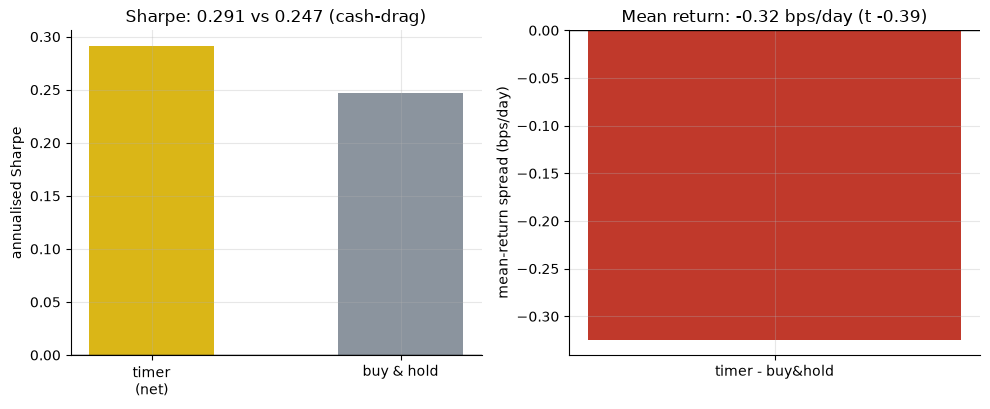

timer Sharpe 0.291 | buy&hold 0.247 | switches/yr 9.6 | mean spread -0.32 bps/d (t -0.39)


In [5]:
if HAVE_REAL:
    ov = st.timing_overlay(DF, cost_bps=2.0)
    ts, bs, sw = ov['timer_sharpe'], ov['bh_sharpe'], ov['switches_per_yr']
    sp, spt = ov['spread_bps_day'], ov['spread_t']
else:
    ts, bs, sw = 0.291, 0.247, 9.6
    sp, spt = -0.32, -0.39
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))
a1.bar(['timer\n(net)','buy & hold'], [ts, bs], color=[AMBER, GREY], width=.5)
a1.set_ylabel('annualised Sharpe'); a1.set_title(f'Sharpe: {ts:.3f} vs {bs:.3f} (cash-drag)')
a1.axhline(0, c='k', lw=1)
a2.bar(['timer - buy&hold'], [sp], color=(RED if sp<0 else GREEN), width=.4)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('mean-return spread (bps/day)')
a2.set_title(f'Mean return: {sp:+.2f} bps/day (t {spt:+.2f})')
plt.tight_layout(); plt.show()
print(f'timer Sharpe {ts:.3f} | buy&hold {bs:.3f} | switches/yr {sw:.1f} | mean spread {sp:+.2f} bps/d (t {spt:+.2f})')

> 💡 In plain words: the timer's *Sharpe* edge is an illusion — it sits in cash 57% of the time, trimming volatility more than return. On the honest metric (mean return) it **loses** 0.32 bps/day (*t* -0.39) while churning 9.6 round-trips a year. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real timing edge (`tp_signal > 0`) of increasing strength and watch the Q5−Q1 HAC *t* rise — averaged over 25 seeds so no single lucky seed can fake it.

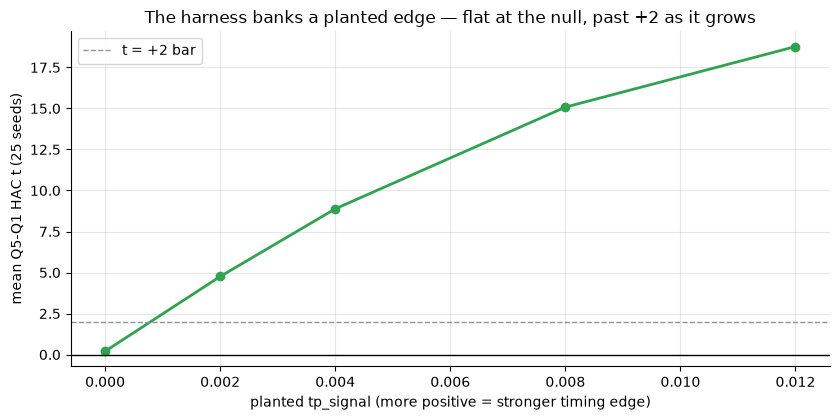

tp_signal +0.000 -> mean spread +0.11%, mean HAC t +0.20
tp_signal +0.002 -> mean spread +2.58%, mean HAC t +4.76
tp_signal +0.004 -> mean spread +5.06%, mean HAC t +8.88
tp_signal +0.008 -> mean spread +10.01%, mean HAC t +15.08
tp_signal +0.012 -> mean spread +14.97%, mean HAC t +18.77


In [6]:
signals = [0.0, 0.002, 0.004, 0.008, 0.012]
res = [st.synthetic_mean_t(data, tp_signal=a, n_seeds=25, horizon=21) for a in signals]
ts = [r['mean_t'] for r in res]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(signals, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted tp_signal (more positive = stronger timing edge)')
ax.set_ylabel('mean Q5-Q1 HAC t (25 seeds)')
ax.set_title('The harness banks a planted edge — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, r in zip(signals, res): print(f'tp_signal {a:+.3f} -> mean spread {r["mean_spread"]*100:+.2f}%, mean HAC t {r["mean_t"]:+.2f}')

The mean HAC *t* is ≈ 0 at the null (no false positive) and climbs far past +2 as the planted edge grows — so the engine is a faithful detector. The real-tape result is therefore a statement about **this ACM-proxy tape**: the term-premium timing edge is right-signed but faint and regime-dependent here. For the raw-slope cousin, see [132 Yield-Curve-Steepener](../../132-yield-curve-steepener/).